# Lab 26 — A Small Cellular-System Simulator: Reuse, Traffic, Random Access, Coverage and Scheduling

**Companion to Chapter 20** (*Multiple Access and the Cellular Concept*). Lab 11 introduces several of these ideas in a few
cells each; this lab turns Chapter 20's figures into a system simulator you can push on.
**Time needed:** about 2 hours. **Difficulty:** core.

A cellular network is a machine for reusing a scarce spectrum as many times per square kilometre as interference allows,
and for sharing each reuse among users who arrive at random, contend for access, and see channels that fade. Each section
answers one of the system engineer's questions with the code that drew the chapter's figure (`commlib/cellular.py`):
how far apart must co-channel cells be; how many channels does a cell need for a given blocking; how much traffic can
a random-access channel carry before it collapses; what fraction of a randomly deployed network is covered; and how
should a scheduler divide the slots between a user near the mast and one at the edge?

### What you will learn
1. Build hexagonal reuse patterns and compute co-channel SIR from geometry, with and without sectors and shadowing.
2. Dimension cells with Erlang B and C, check them against an event-driven call simulation, and see trunking efficiency.
3. Simulate pure and slotted ALOHA, CSMA, the instability of slotted ALOHA, and RACH preamble collisions.
4. Compare Poisson-point-process coverage with the Andrews–Baccelli–Ganti closed form, and with a hexagonal grid.
5. Measure multiuser-diversity gain and the throughput–fairness trade-off of proportional-fair and α-fair schedulers.

### Prerequisites
Lab 5 (path loss, shadowing, fading), Lab 11 (sections 1, 2, 4, 7). Basic probability (Poisson process). Chapter 20.

### Roadmap
| § | Topic | Interactive |
|---|-------|:-----------:|
| 1 | Hexagonal clusters and co-channel SIR | yes |
| 2 | SIR maps and CDFs: sectors and shadowing | yes |
| 3 | Erlang B and C, trunking efficiency, a call simulator | yes |
| 4 | Random access: ALOHA, CSMA, instability, RACH | yes |
| 5 | Stochastic geometry: PPP coverage | yes |
| 6 | Scheduling: multiuser diversity and α-fairness | yes |

In [1]:
import os, sys
os.environ.setdefault("OPENBLAS_NUM_THREADS", "2")   # small matrices: avoid BLAS thread thrashing
sys.path[:0] = [p for p in (os.path.abspath(".."), os.path.abspath("."))
                if os.path.isdir(os.path.join(p, "commlib"))]
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import RegularPolygon
from scipy.optimize import brentq
import commlib as cl
from commlib import cellular as cel
from commlib import labkit as lk

rng = lk.setup(seed=26, lab="26")
PALE = ["#C9D6E8", "#F2C9C4", "#C8E3D3", "#F5D9BF", "#DCCFE6", "#C6DEEF", "#E3E3D1", "#F0E0A8", "#D5D5D5",
        "#BFE0DC", "#EBC8DF", "#D9E6B8", "#E6CFC0"]


def hexpatch(ax, x, y, R=1.0, **kw):
    ax.add_patch(RegularPolygon((x, y), 6, radius=R, orientation=0, **kw))

Lab 26 ready | numpy 2.5.3 | scipy 1.18.1 | matplotlib 3.11.2 | seed 26


## 1. Hexagonal clusters and co-channel SIR

On a hexagonal lattice, co-channel cells can be placed by moving $i$ cells along one axis, turning 60° and moving $j$
cells: the **cluster size** is $N = i^2 + ij + j^2 \in \{1, 3, 4, 7, 9, 12, 13, \ldots\}$ and the co-channel distance is
$D = R\sqrt{3N}$. With six first-tier interferers all at distance $D$ and path-loss exponent $n$, a user at the cell edge sees
$$\frac{S}{I} \approx \frac{(D/R)^n}{6} = \frac{(3N)^{n/2}}{6}.$$
Rappaport's worst case puts two interferers at $D-R$, two at $D$ and two at $D+R$. Chapter 20's AMPS example: FM voice
needs about 18 dB; with $n = 4$, $N = 7$ gives 18.7 dB (worst case 17.3 dB).

### Interactive: reuse pattern

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

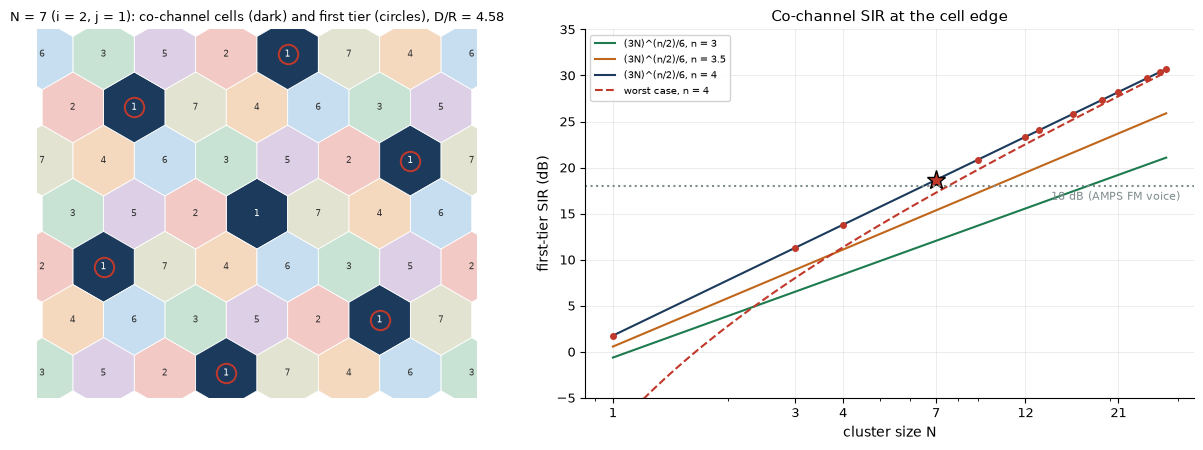

,
cluster size N,7
reuse ratio Q = D/R,4.58
(3N)^(n/2)/6 at n = 4,18.7 dB
worst case at n = 4,17.3 dB
three sectors (2 interferers): Q^n / 2,23.4 dB


In [3]:
def cluster_demo(i=2, j=1, n=4.0):
    N = cel.cluster_size(i, j)
    q, r = cel.hex_axial_grid(5)
    lab = cel.reuse_labels(q, r, i, j)
    x, y = cel.axial_to_xy(q, r)
    f, ax = lk.fig((12.5, 4.6), 1, 2, gridspec_kw=dict(width_ratios=[1, 1.15]))
    for xx, yy, L in zip(x, y, lab):
        if abs(xx) > 6.2 or abs(yy) > 5.4:
            continue
        hexpatch(ax[0], xx, yy, facecolor=lk.NAVY if L == 0 else PALE[L % len(PALE)], edgecolor="white", lw=0.6)
        ax[0].text(xx, yy, str(L + 1), ha="center", va="center", fontsize=6.5, color="white" if L == 0 else "#333")
    cc = cel.cochannel_centres(i, j, tiers=1)
    ax[0].plot(cc.real, cc.imag, "o", mfc="none", mec=lk.RED, ms=14, mew=1.4)
    ax[0].set_xlim(-6.2, 6.2); ax[0].set_ylim(-5.2, 5.2); ax[0].set_aspect("equal"); ax[0].axis("off")
    ax[0].set_title(f"N = {N} (i = {i}, j = {j}): co-channel cells (dark) and first tier (circles), D/R = {np.sqrt(3 * N):.2f}", fontsize=9)
    Ns = np.linspace(1, 28, 300)
    for nn, col in [(3.0, lk.GREEN), (3.5, lk.ORANGE), (4.0, lk.NAVY)]:
        ax[1].plot(Ns, lk.db(cel.sir_simple(Ns, nn)), color=col, label=f"(3N)^(n/2)/6, n = {nn:g}")
    ax[1].plot(Ns, lk.db(cel.sir_worst(Ns, n)), "--", color=lk.RED, label=f"worst case, n = {n:g}")
    vs = [v[0] for v in cel.valid_cluster_sizes(28)]
    ax[1].plot(vs, lk.db(cel.sir_simple(np.array(vs), n)), "o", ms=4, color=lk.RED)
    ax[1].plot([N], [lk.db(cel.sir_simple(N, n))], "*", ms=14, color=lk.RED, mec="k")
    ax[1].axhline(18, color=lk.GRAY, ls=":"); ax[1].text(14, 16.5, "18 dB (AMPS FM voice)", fontsize=8, color=lk.GRAY)
    ax[1].set_xscale("log"); ax[1].set_xticks([1, 3, 4, 7, 12, 21]); ax[1].set_xticklabels(["1", "3", "4", "7", "12", "21"])
    ax[1].set_xlabel("cluster size N"); ax[1].set_ylabel("first-tier SIR (dB)"); ax[1].legend(fontsize=7.5, loc="upper left")
    ax[1].set_title("Co-channel SIR at the cell edge"); ax[1].set_ylim(-5, 35)
    lk.show(f)
    lk.table([["cluster size N", N], ["reuse ratio Q = D/R", f"{np.sqrt(3 * N):.2f}"],
              [f"(3N)^(n/2)/6 at n = {n:g}", f"{lk.db(cel.sir_simple(N, n)):.1f} dB"],
              [f"worst case at n = {n:g}", f"{lk.db(cel.sir_worst(N, n)):.1f} dB"],
              ["three sectors (2 interferers): Q^n / 2", f"{lk.db(np.sqrt(3 * N) ** n / 2):.1f} dB"]], ["", ""])

lk.interact(cluster_demo, i=lk.islider(2, 1, 4, 1, "i"), j=lk.islider(1, 0, 3, 1, "j"),
            n=lk.slider(4.0, 2.5, 5.0, 0.1, "path-loss exponent n"))

**What you should see.** With $(i, j) = (2, 1)$ the pattern is the classic 7-cell cluster, with the six nearest co-channel
cells ringed at $D = 4.58R$. The table reproduces the chapter: 18.7 dB from the simple formula and 17.3 dB worst case,
while three 120° sectors (only two first-tier interferers face each sector) raise the estimate to 23.4 dB. Try $n = 3$:
the same SIR now needs a much larger cluster, so propagation that falls off quickly with distance is a friend of reuse.

### Try it yourself 1.1
With $n = 3.5$ and an 18 dB target, what is the smallest *valid* cluster size by the simple formula?

In [5]:
answer_1_1 = None
need = next(N for N, _, _ in cel.valid_cluster_sizes(40) if lk.db(cel.sir_simple(N, 3.5)) >= 18)
lk.check("1.1 smallest valid N for 18 dB at n = 3.5", answer_1_1, need, atol=0)

[TODO] 1.1 smallest valid N for 18 dB at n = 3.5: not attempted yet: replace the None with your answer

## 2. SIR maps and CDFs: sectors and shadowing

The formula assumes every user is at the cell edge and the path loss is deterministic. Drop users uniformly in the cell,
add log-normal **shadowing** (independent on each link), and use two tiers of co-channel interferers, and SIR becomes a
distribution. Three-sector sites use antennas with the 3GPP pattern $-\min(12(\theta/65°)^2, 20)$ dB. Chapter 20's
simulation: with 8 dB shadowing and $n = 4$, the 18 dB target is met at about 60% of locations in an omnidirectional
$N = 7$ layout and about 80% with sectors.

### Interactive: layout

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

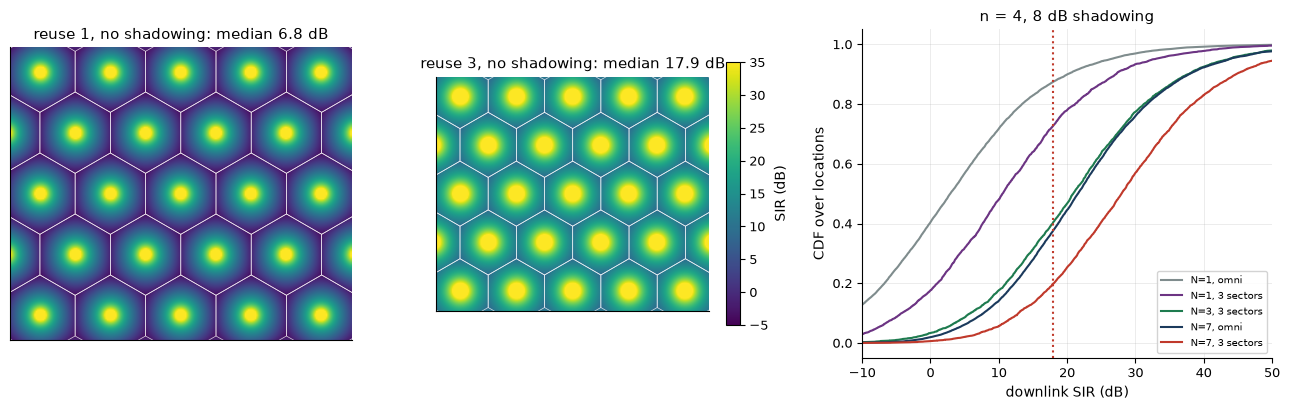

layout,median SIR (dB),5th percentile (dB),% locations ≥ 18 dB
"N=1, omni",2.9,-15.5,12.5
"N=1, 3 sectors",10.6,-7.8,27.2
"N=3, 3 sectors",20.9,2.3,59.5
"N=7, omni",21.6,3.9,62.2
"N=7, 3 sectors",28.0,9.2,80.1


In [7]:
def sector_gain_db(theta_deg, bw=65.0, am=20.0):
    th = (np.asarray(theta_deg) + 180) % 360 - 180
    return -np.minimum(12 * (th / bw) ** 2, am)


def sir_samples(i, j, n=4.0, sigma=8.0, sectors=1, users=20000, r_=None, tiers=2):
    """Downlink SIR (dB) of users dropped in the central cell (sector facing 0°), co-channel reuse (i, j)."""
    r_ = np.random.default_rng(7) if r_ is None else r_
    u = cel.drop_in_hex(users, rng=r_, rmin=0.05)
    if sectors == 3:
        u = u[np.abs(np.angle(u, deg=True)) < 60]
    if (i, j) == (1, 0):                                    # reuse 1: every neighbour is co-channel
        q, rr = cel.hex_axial_grid(2 * tiers); x, y = cel.axial_to_xy(q, rr); bs = (x + 1j * y)[1:]
    else:
        bs = cel.cochannel_centres(i, j, tiers=tiers)
    sh = lambda shape: 10 ** (sigma * r_.standard_normal(shape) / 10)
    S = np.abs(u) ** -n * sh(len(u))
    d = u[:, None] - bs[None, :]
    g = np.abs(d) ** -n * sh((len(u), len(bs)))
    if sectors == 3:
        S = S * 10 ** (sector_gain_db(np.angle(u, deg=True)) / 10)
        g = g * 10 ** (sector_gain_db(np.angle(d, deg=True)) / 10)
    return lk.db(S / g.sum(axis=1))


def sir_demo(sigma=8.0, n=4.0, target=18.0):
    f, ax = lk.fig((13, 4.2), 1, 3, gridspec_kw=dict(width_ratios=[1, 1, 1.2]))
    q, r = cel.hex_axial_grid(5)
    sx, sy = cel.axial_to_xy(q, r); sites = sx + 1j * sy
    xs = np.linspace(-4.2, 4.2, 240); ys = np.linspace(-3.6, 3.6, 210)
    X, Y = np.meshgrid(xs, ys); P = X + 1j * Y
    d = np.maximum(np.abs(P[..., None] - sites[None, None, :]), 0.04)
    pw = d ** -n; best = np.argmin(d, axis=-1)
    for a, (i, j), ttl in [(ax[0], (1, 0), "reuse 1"), (ax[1], (1, 1), "reuse 3")]:
        lab = cel.reuse_labels(q, r, i, j) if (i, j) != (1, 0) else np.zeros(len(q), int)
        S = np.take_along_axis(pw, best[..., None], -1)[..., 0]
        same = lab[None, None, :] == lab[best][..., None]
        sir = lk.db(S / (np.sum(pw * same, axis=-1) - S))
        im = a.imshow(sir, extent=[xs[0], xs[-1], ys[0], ys[-1]], origin="lower", cmap="viridis", vmin=-5, vmax=35, interpolation="bilinear")
        for xx, yy in zip(sx, sy):
            if abs(xx) < 5 and abs(yy) < 4.5:
                hexpatch(a, xx, yy, facecolor="none", edgecolor="white", lw=0.5, alpha=0.8)
        a.set_xlim(xs[0], xs[-1]); a.set_ylim(ys[0], ys[-1]); a.set_aspect("equal"); a.set_xticks([]); a.set_yticks([]); a.grid(False)
        a.set_title(f"{ttl}, no shadowing: median {np.median(sir):.1f} dB")
    plt.colorbar(im, ax=ax[1], shrink=0.8, label="SIR (dB)")
    rows = []
    for (i, j, sec, col, lab) in [(1, 0, 1, lk.GRAY, "N=1, omni"), (1, 0, 3, lk.PURPLE, "N=1, 3 sectors"), (1, 1, 3, lk.GREEN, "N=3, 3 sectors"),
                                  (2, 1, 1, lk.NAVY, "N=7, omni"), (2, 1, 3, lk.RED, "N=7, 3 sectors")]:
        v = np.sort(sir_samples(i, j, n=n, sigma=sigma, sectors=sec, users=12000))
        ax[2].plot(v, np.arange(1, len(v) + 1) / len(v), color=col, label=lab)
        rows.append([lab, np.median(v), np.percentile(v, 5), 100 * np.mean(v >= target)])
    ax[2].axvline(target, color=lk.RED, ls=":"); ax[2].set_xlim(-10, 50)
    ax[2].set_xlabel("downlink SIR (dB)"); ax[2].set_ylabel("CDF over locations"); ax[2].legend(fontsize=7.5, loc="lower right")
    ax[2].set_title(f"n = {n:g}, {sigma:g} dB shadowing")
    lk.show(f)
    lk.table(rows, ["layout", "median SIR (dB)", "5th percentile (dB)", f"% locations ≥ {target:g} dB"], fmt=".1f")

lk.interact(sir_demo, sigma=lk.slider(8, 0, 12, 0.5, "shadowing σ (dB)"), n=lk.slider(4.0, 2.5, 5.0, 0.1, "path-loss exponent"),
            target=lk.slider(18, 0, 25, 1, "SIR target (dB)"))

**What you should see.** The reuse-1 map is dark (near 0 dB) along every cell edge; reuse 3 lifts the edges by roughly
10 dB. With 8 dB shadowing the $N = 7$ omni layout meets 18 dB at roughly 60% of locations and the sectorised one at roughly
80%, matching Chapter 20: shadowing, not geometry, sets the margins. Reuse 1 with sectors has a median SIR of only a few dB,
yet it is what LTE and NR use: their coding, link adaptation and HARQ work at SINRs down to about −5 dB, and the capacity
gain of reusing every channel in every sector beats the SIR loss. Set σ = 0 to recover the geometric picture.

## 3. Erlang B and C, trunking efficiency, a call simulator

Calls arrive as a Poisson process and last an exponential time with mean $h$; the offered traffic is $A = \lambda h$
erlangs. With $C$ channels and blocked calls cleared, the blocking probability is **Erlang B**,
$B(A, C) = \frac{A^C/C!}{\sum_{k=0}^C A^k/k!}$; with blocked calls queued, the probability of waiting is **Erlang C**. Large
trunks are more efficient: 57 channels carry 46.8 E at 2% blocking (82% occupancy), three trunks of 19 only $3\times 12.3$ E
(Chapter 20's AMPS sectorisation example). Below, an event-driven simulation of a loss system checks the formula.

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

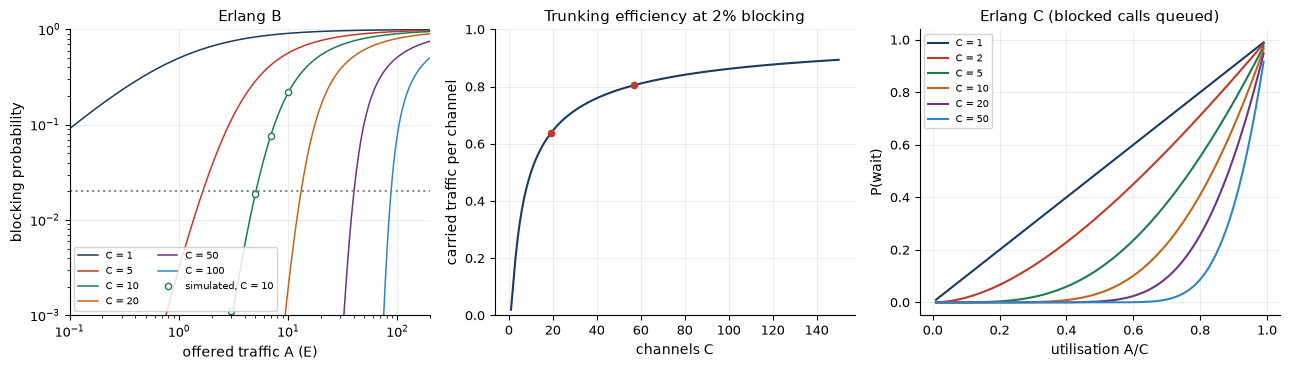

configuration,traffic at 2% (E),subscribers at 0.033 E
one trunk of 57,46.8,1419
3 sectors of 19,37.0,1121
trunking loss of sectorisation,21%,
"queued instead (Erlang C) at 0.95×46.8 E: P(wait), mean wait",0.05,0.5 s


In [9]:
def loss_sim(A, C, n_calls=40000, rng=rng):
    """Event-driven M/M/C/C simulation: returns the fraction of blocked calls (mean holding time 1)."""
    t = np.cumsum(rng.exponential(1 / A, n_calls))
    hold = rng.exponential(1.0, n_calls)
    ends = np.full(C, -1.0)                                   # end time of the call on each channel
    blocked = 0
    for k in range(n_calls):
        free = np.flatnonzero(ends <= t[k])
        if len(free):
            ends[free[0]] = t[k] + hold[k]
        else:
            blocked += 1
    return blocked / n_calls


def erlang_demo(C=57, gos=2.0, sectors=3, hold_s=120.0):
    g = gos / 100
    A_tot = cel.erlang_b_capacity(C, g)
    Cs = C // sectors
    A_sec = cel.erlang_b_capacity(Cs, g)
    f, ax = lk.fig((13, 3.8), 1, 3)
    A = np.logspace(-1, 2.3, 300)
    for c, col in zip([1, 5, 10, 20, 50, 100], lk.PALETTE):
        ax[0].loglog(A, cel.erlang_b(A, c), color=col, lw=1.1, label=f"C = {c}")
    sims = [(a_, loss_sim(a_, 10)) for a_ in (3.0, 5.0, 7.0, 10.0)]
    ax[0].loglog([s[0] for s in sims], [s[1] for s in sims], "o", color=lk.PALETTE[2], mfc="white", label="simulated, C = 10")
    ax[0].axhline(g, color=lk.GRAY, ls=":"); ax[0].set_ylim(1e-3, 1); ax[0].set_xlim(0.1, 200)
    ax[0].set_xlabel("offered traffic A (E)"); ax[0].set_ylabel("blocking probability"); ax[0].legend(fontsize=7, ncol=2); ax[0].set_title("Erlang B")
    cs = np.arange(1, 151)
    ax[1].plot(cs, [cel.erlang_b_capacity(c, g) * (1 - g) / c for c in cs], color=lk.NAVY)
    ax[1].plot([C, Cs], [A_tot * (1 - g) / C, A_sec * (1 - g) / Cs], "o", color=lk.RED)
    ax[1].set_xlabel("channels C"); ax[1].set_ylabel("carried traffic per channel"); ax[1].set_ylim(0, 1)
    ax[1].set_title(f"Trunking efficiency at {gos:g}% blocking")
    rho = np.linspace(0.01, 0.99, 200)
    for c, col in zip([1, 2, 5, 10, 20, 50], lk.PALETTE):
        ax[2].plot(rho, cel.erlang_c(rho * c, c), color=col, label=f"C = {c}")
    ax[2].set_xlabel("utilisation A/C"); ax[2].set_ylabel("P(wait)"); ax[2].legend(fontsize=7); ax[2].set_title("Erlang C (blocked calls queued)")
    lk.show(f)
    pw, wbar = cel.erlang_c_wait(A_tot * 0.95, C, hold_s)
    lk.table([[f"one trunk of {C}", f"{A_tot:.1f}", f"{A_tot / 0.033:.0f}"],
              [f"{sectors} sectors of {Cs}", f"{sectors * A_sec:.1f}", f"{sectors * A_sec / 0.033:.0f}"],
              ["trunking loss of sectorisation", f"{100 * (1 - sectors * A_sec / A_tot):.0f}%", ""],
              [f"queued instead (Erlang C) at 0.95×{A_tot:.1f} E: P(wait), mean wait", f"{float(pw):.2f}", f"{float(wbar):.1f} s"]],
             ["configuration", f"traffic at {gos:g}% (E)", "subscribers at 0.033 E"])

lk.interact(erlang_demo, C=lk.islider(57, 5, 150, 1, "channels per cell"), gos=lk.slider(2, 0.5, 10, 0.5, "grade of service (%)"),
            sectors=lk.choice([1, 3, 6], 3, "sectors"), hold_s=lk.slider(120, 30, 600, 10, "mean holding time (s)"))

**What you should see.** The simulated blocking of a 10-channel system lies on its Erlang B curve. The table reproduces the
AMPS example: 57 channels carry 46.8 E (about 1400 subscribers at 0.033 E each); three sectors of 19 carry 37.0 E (about
1110), a 21% trunking loss. Sectors pay for themselves only when their SIR gain buys a tighter reuse (Try it 3.1).
Erlang C shows the queueing alternative: a 57-channel queue offered 95% of the Erlang B load (about 44 E) makes only about 5% of
calls wait, for half a second on average over all calls; but the curves show how steeply the probability of waiting rises as
$A \to C$, and small trunks queue long before they are busy.

### Try it yourself 3.1
Chapter 20, part (c): with three sectors and $N = 4$, each sector has 33 channels. How many erlangs does the *cell* carry at 2%?

In [11]:
answer_3_1 = None
lk.check("3.1 cell traffic, 3 sectors of 33 channels at 2% (E)", answer_3_1, 3 * cel.erlang_b_capacity(33, 0.02), atol=0.3)

[TODO] 3.1 cell traffic, 3 sectors of 33 channels at 2% (E): not attempted yet: replace the None with your answer

## 4. Random access: ALOHA, CSMA, instability, RACH

With Poisson attempts at $G$ per packet time, a pure-ALOHA packet survives if nobody else starts within one packet time
either side: $S = Ge^{-2G}$, peaking at $1/(2e) = 0.184$. Slotting halves the vulnerable period: $S = Ge^{-G}$, peak
$1/e = 0.368$. Listening first (CSMA) does far better when the propagation delay is a small fraction $a$ of a packet.
Below, an event-driven simulation checks the ALOHA formulas, and Chapter 20's sensor-network example asks whether 500 sensors
sending a 50-byte report per minute at 10 kb/s can share a channel.

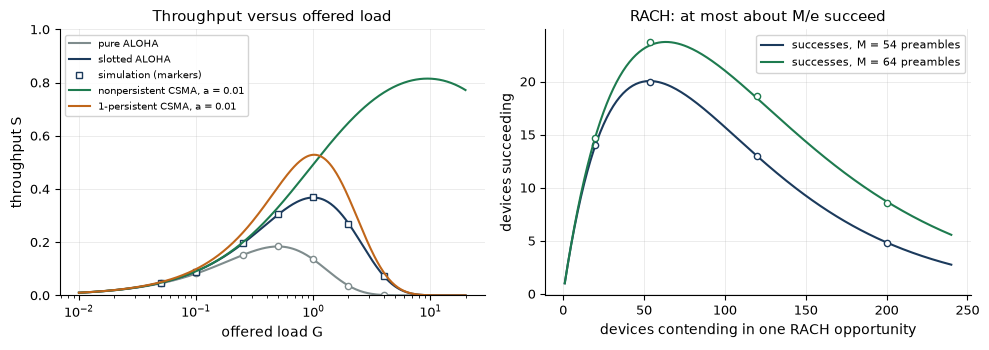

Chapter 20: slotted ALOHA for 500 sensors,
packet time,40 ms
new-packet load S,0.333
pure ALOHA can carry it?,no
slotted ALOHA: G on the stable branch,0.62
transmissions per report G/S,1.86
success probability per attempt,0.54
saturation: number of sensors,552


In [13]:
def aloha_sim(G, slotted, T=20000, rng=rng):
    n = rng.poisson(G * T)
    if slotted:
        cnt = np.bincount(rng.integers(0, T, n), minlength=T)
        return np.sum(cnt == 1) / T
    t = np.sort(rng.random(n) * T)
    gap = np.diff(t)
    ok = np.r_[True, gap > 1] & np.r_[gap > 1, True]
    return ok.sum() / T

Gs = np.logspace(-2, 1.3, 400)
Gsim = np.array([0.05, 0.1, 0.25, 0.5, 1, 2, 4])
f, ax = lk.fig("row2", 1, 2)
ax[0].semilogx(Gs, cel.aloha_throughput(Gs), color=lk.GRAY, label="pure ALOHA")
ax[0].semilogx(Gsim, [aloha_sim(g, False) for g in Gsim], "o", color=lk.GRAY, mfc="white")
ax[0].semilogx(Gs, cel.aloha_throughput(Gs, True), color=lk.NAVY, label="slotted ALOHA")
ax[0].semilogx(Gsim, [aloha_sim(g, True) for g in Gsim], "s", color=lk.NAVY, mfc="white", label="simulation (markers)")
for kind, col in [("nonpersistent", lk.GREEN), ("1-persistent", lk.ORANGE)]:
    ax[0].semilogx(Gs, cel.csma_throughput(Gs, 0.01, kind), color=col, label=f"{kind} CSMA, a = 0.01")
ax[0].set_xlabel("offered load G"); ax[0].set_ylabel("throughput S"); ax[0].legend(fontsize=7.5); ax[0].set_ylim(0, 1)
ax[0].set_title("Throughput versus offered load")
k = np.arange(1, 241)
for M, col in [(54, lk.NAVY), (64, lk.GREEN)]:
    ax[1].plot(k, cel.rach_success(k, M), color=col, label=f"successes, M = {M} preambles")
    sim = []
    for kc in (20, 54, 120, 200):                           # Monte Carlo: count preambles chosen by exactly one device
        pre = rng.integers(0, M, (500, kc)) + M * np.arange(500)[:, None]
        sim.append(np.mean(np.sum(np.bincount(pre.ravel(), minlength=500 * M).reshape(500, M) == 1, axis=1)))
    ax[1].plot([20, 54, 120, 200], sim, "o", color=col, mfc="white")
ax[1].set_xlabel("devices contending in one RACH opportunity"); ax[1].set_ylabel("devices succeeding"); ax[1].legend(fontsize=8)
ax[1].set_title("RACH: at most about M/e succeed")
lk.show(f)
S = 500 / (60 / (400 / 1e4))
G_st = brentq(lambda g: g * np.exp(-g) - S, 1e-6, 1)
lk.table([["packet time", "40 ms"], ["new-packet load S", f"{S:.3f}"], ["pure ALOHA can carry it?", "no" if S > 1 / (2 * np.e) else "yes"],
          ["slotted ALOHA: G on the stable branch", f"{G_st:.2f}"], ["transmissions per report G/S", f"{G_st / S:.2f}"],
          ["success probability per attempt", f"{np.exp(-G_st):.2f}"], ["saturation: number of sensors", f"{1500 / np.e:.0f}"]],
         ["Chapter 20: slotted ALOHA for 500 sensors", ""])

**What you should see.** Simulation on theory for both ALOHA variants; nonpersistent CSMA with $a = 0.01$ reaches about 0.8.
For the sensor network: $S = 0.333$ exceeds pure ALOHA's 0.184, but slotted ALOHA carries it at $G = 0.62$, so every report
is sent 1.86 times on average, and the network saturates at about 550 sensors. A RACH opportunity with 54 preambles lets at most
about 20 devices through, however many try.

**Instability.** The throughput curve has two operating points for every $S < 1/e$, and the right-hand one is a trap. Below,
a finite population of backlogged users retransmits with a fixed probability: once a burst of collisions pushes the backlog
up, the retransmissions themselves keep the channel jammed. A pseudo-Bayesian controller ($q_r = 1/\hat n$, Rivest) tracks
the backlog and stays stable.

### Interactive: offered load and retransmission control

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

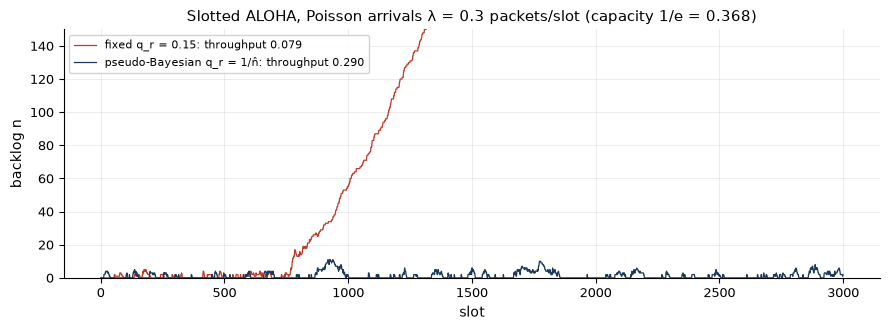

In [15]:
def stability_demo(lam=0.30, q_fixed=0.15, slots=3000):
    r = np.random.default_rng(3)
    f, ax = lk.fig("wide")
    for mode, col, lab in [("fixed", lk.RED, f"fixed q_r = {q_fixed:g}"), ("pb", lk.NAVY, "pseudo-Bayesian q_r = 1/n̂")]:
        n = 0; nhat = 0.0; trace = []; succ = 0
        for s in range(slots):
            new = r.poisson(lam)
            q = q_fixed if mode == "fixed" else min(1.0, 1 / max(nhat, 1.0))
            ret = r.binomial(n, q)
            tot = new + ret
            if tot == 1:
                succ += 1
                n -= ret
            elif tot > 1:
                n += new
            nhat = max(lam, nhat + lam - 1) if tot <= 1 else nhat + lam + 1 / (np.e - 2)
            trace.append(n)
        ax.plot(trace, color=col, lw=0.9, label=f"{lab}: throughput {succ / slots:.3f}")
    ax.set_xlabel("slot"); ax.set_ylabel("backlog n"); ax.set_ylim(0, 150); ax.legend(fontsize=8, loc="upper left")
    ax.set_title(f"Slotted ALOHA, Poisson arrivals λ = {lam:g} packets/slot (capacity 1/e = 0.368)")
    lk.show(f)

lk.interact(stability_demo, lam=lk.slider(0.30, 0.05, 0.40, 0.01, "arrival rate λ"),
            q_fixed=lk.slider(0.15, 0.01, 0.5, 0.01, "fixed retransmission probability"), slots=lk.choice([1000, 3000, 10000], 3000, "slots"))

**What you should see.** With $\lambda = 0.30$ and a fixed $q_r = 0.15$ the backlog wanders and then runs away: the
throughput collapses while the backlog grows without bound. The pseudo-Bayesian controller keeps the backlog small and
carries the full $0.30$. Lower λ to 0.15: the fixed scheme survives much longer, but it is only metastable.

### Try it yourself 4.1
What is the maximum number of sensors of the example if the network uses *pure* ALOHA?

In [17]:
answer_4_1 = None
lk.check("4.1 pure-ALOHA sensor limit", answer_4_1, 1500 / (2 * np.e), atol=3)

[TODO] 4.1 pure-ALOHA sensor limit: not attempted yet: replace the None with your answer

## 5. Stochastic geometry: PPP coverage

Real base stations are not on a hexagonal grid. Model them as a **Poisson point process** of density λ, attach each user to
the nearest one, and add Rayleigh fading: Andrews, Baccelli and Ganti (2011) showed that the interference-limited coverage
$P[\mathrm{SINR} > T] = 1/(1 + \rho(T, \alpha))$ does **not depend on the density**. With $\alpha = 4$,
$\rho = \sqrt T(\pi/2 - \arctan(1/\sqrt T))$. A hexagonal grid is an upper bound, a PPP a pessimistic lower one; real
networks fall in between. With noise, densification helps only until the network becomes interference-limited.

### Interactive: path-loss exponent

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

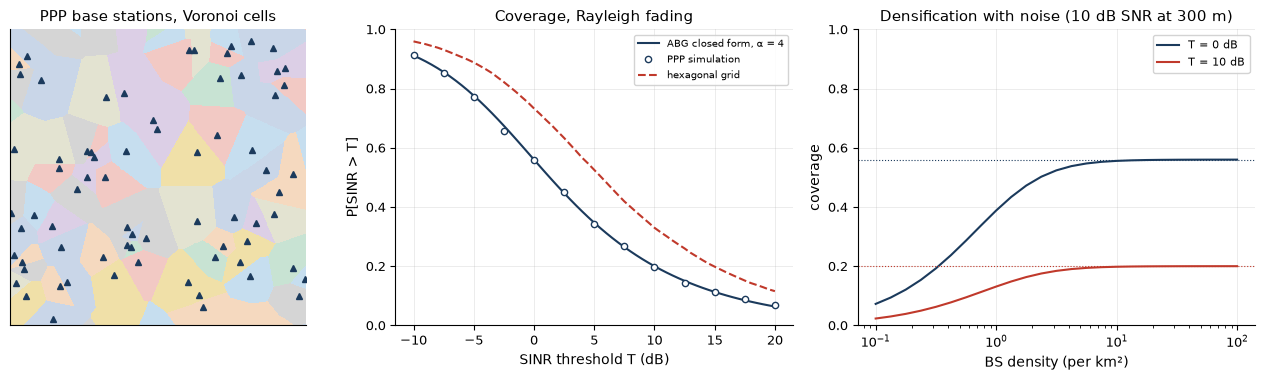

α = 4,
"P[SINR > 0 dB], PPP formula",0.560
"P[SINR > 0 dB], PPP simulation",0.557
"P[SINR > 0 dB], hexagonal",0.733
"mean spectral efficiency, PPP (b/s/Hz)",2.13


In [19]:
def ppp_demo(alpha=4.0, trials=1500):
    r = np.random.default_rng(21)
    TdB = np.linspace(-10, 20, 61); T = lk.undb(TdB)
    f, ax = lk.fig((13, 3.9), 1, 3, gridspec_kw=dict(width_ratios=[1, 1.15, 1.15]))
    bs = cel.ppp_drop(1.0, 12, r)
    xs = np.linspace(-4, 4, 300); X, Y = np.meshgrid(xs, xs)
    owner = np.argmin(np.abs((X + 1j * Y)[..., None] - bs[None, None, :]), axis=-1)
    ax[0].imshow(owner % 9, extent=[-4, 4, -4, 4], origin="lower", cmap=plt.matplotlib.colors.ListedColormap(PALE[:9]), interpolation="nearest")
    sel = (np.abs(bs.real) < 4) & (np.abs(bs.imag) < 4)
    ax[0].plot(bs.real[sel], bs.imag[sel], "^", ms=4, color=lk.NAVY); ax[0].set_aspect("equal"); ax[0].grid(False)
    ax[0].set_xticks([]); ax[0].set_yticks([]); ax[0].set_title("PPP base stations, Voronoi cells")
    ax[1].plot(TdB, cel.abg_coverage(T, alpha), color=lk.NAVY, label=f"ABG closed form, α = {alpha:g}")
    s = cel.ppp_sinr_samples(1.0, alpha, trials=trials, rng=r)
    ax[1].plot(TdB[::5], [(s > lk.undb(t)).mean() for t in TdB[::5]], "o", color=lk.NAVY, mfc="white", label="PPP simulation")
    q, rr = cel.hex_axial_grid(6); x, y = cel.axial_to_xy(q, rr)
    R = np.sqrt(2 / (3 * np.sqrt(3))); sites = (x + 1j * y) * R
    u = cel.drop_in_hex(20000, R=R, rng=r)
    d = np.abs(u[:, None] - sites[None, :]); p = r.exponential(size=d.shape) * d ** -alpha
    h = p[:, 0] / (p.sum(axis=1) - p[:, 0])
    ax[1].plot(TdB, [(h > t).mean() for t in T], "--", color=lk.RED, label="hexagonal grid")
    ax[1].set_xlabel("SINR threshold T (dB)"); ax[1].set_ylabel("P[SINR > T]"); ax[1].set_ylim(0, 1); ax[1].legend(fontsize=7.5)
    ax[1].set_title("Coverage, Rayleigh fading")
    lam = np.logspace(-1, 2, 25); snr1 = 10 * 300.0 ** alpha
    for T0, col in [(1.0, lk.NAVY), (10.0, lk.RED)]:
        ax[2].semilogx(lam, [cel.abg_coverage([T0], alpha, snr=snr1, lam=l_ * 1e-6)[0] for l_ in lam], color=col, label=f"T = {lk.db(T0):.0f} dB")
        ax[2].axhline(cel.abg_coverage([T0], alpha)[0], color=col, ls=":", lw=0.8)
    ax[2].set_xlabel("BS density (per km²)"); ax[2].set_ylabel("coverage"); ax[2].set_ylim(0, 1); ax[2].legend(fontsize=8)
    ax[2].set_title("Densification with noise (10 dB SNR at 300 m)")
    lk.show(f)
    lk.table([["P[SINR > 0 dB], PPP formula", f"{cel.abg_coverage([1.0], alpha)[0]:.3f}"],
              ["P[SINR > 0 dB], PPP simulation", f"{(s > 1).mean():.3f}"], ["P[SINR > 0 dB], hexagonal", f"{(h > 1).mean():.3f}"],
              ["mean spectral efficiency, PPP (b/s/Hz)", f"{np.mean(np.log2(1 + s)):.2f}"]], [f"α = {alpha:g}", ""])

lk.interact(ppp_demo, alpha=lk.slider(4.0, 2.5, 5.0, 0.25, "path-loss exponent α"), trials=lk.choice([500, 1500, 5000], 1500, "PPP trials"))

**What you should see.** The PPP simulation sits on the closed form; at $T = 0$ dB and $\alpha = 4$ coverage is
$1/(1+\pi/4) = 0.56$. The hexagonal grid is more optimistic by a couple of dB. In the densification panel, coverage rises with
density while the network is noise-limited and then flattens at the interference-limited value (dotted): beyond that point,
adding cells adds capacity per km² but not coverage per user.

### Try it yourself 5.1
Evaluate the closed form for $\alpha = 4$, $T = 0$ dB by hand.

In [21]:
answer_5_1 = None
lk.check("5.1 PPP coverage at T = 0 dB, alpha = 4", answer_5_1, 1 / (1 + np.pi / 4), atol=0.003)

[TODO] 5.1 PPP coverage at T = 0 dB, alpha = 4: not attempted yet: replace the None with your answer

## 6. Scheduling: multiuser diversity and α-fairness

With independent fading, a scheduler that serves the user whose channel is currently best rides the peaks:
**multiuser diversity**. Max-rate maximises cell throughput but starves edge users; **proportional fair** (PF) serves the user
with the largest ratio of instantaneous rate to average throughput, $k^* = \arg\max r_k/\bar R_k$, and the α-fair family
$r_k/\bar R_k^\alpha$ spans max-rate ($\alpha = 0$), PF ($\alpha = 1$) and max-min fairness ($\alpha\to\infty$). Fairness is
measured with Jain's index $(\sum x)^2/(n\sum x^2)$. Chapter 20's worked example: A has $\bar R = 8$, $r = 10$ Mb/s; B has
$\bar R = 1$, $r = 1.5$ Mb/s; max-rate serves A, PF serves B.

### Interactive: users and SNR spread

[info] Interactive panel, shown here at its default settings: run the notebook in Jupyter to move the controls.

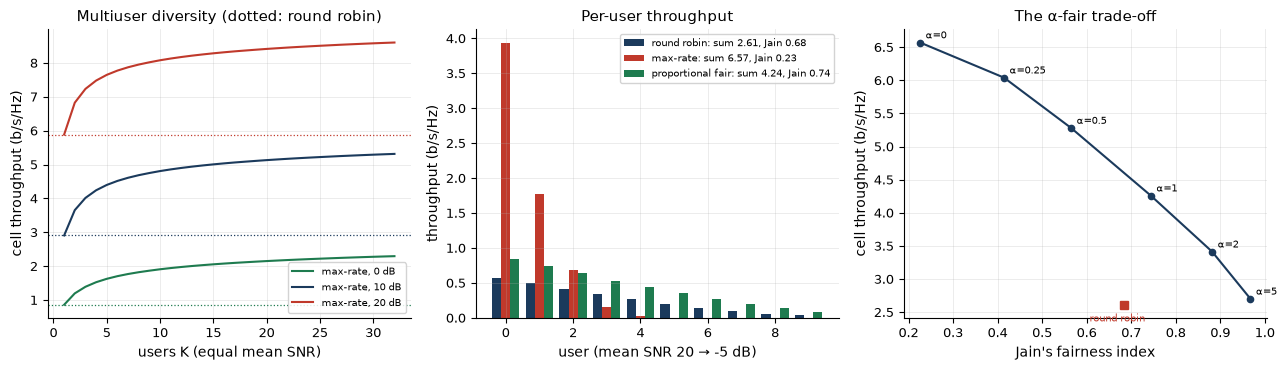

scheduler,cell throughput,edge user,Jain index
round robin,2.614,0.036,0.680
max-rate,6.573,0.000,0.226
proportional fair,4.241,0.085,0.743


In [23]:
def sched_demo(users=10, best_db=20.0, edge_db=-5.0, slots=4000):
    r = np.random.default_rng(40)
    means = lk.undb(np.linspace(best_db, edge_db, users))
    rates = np.log2(1 + means[None, :] * r.exponential(size=(slots, users)))
    pols = {"round robin": cel.schedule(rates, "rr"), "max-rate": cel.schedule(rates, "maxrate"), "proportional fair": cel.schedule(rates, "pf")}
    f, ax = lk.fig((13, 3.8), 1, 3)
    Ks = np.arange(1, 33); h = r.exponential(size=(50000, 32)); run = np.maximum.accumulate(h, axis=1)
    for s_db, col in [(0, lk.GREEN), (10, lk.NAVY), (20, lk.RED)]:
        s = lk.undb(s_db)
        ax[0].plot(Ks, np.log2(1 + s * run).mean(0), color=col, label=f"max-rate, {s_db} dB")
        ax[0].axhline(np.log2(1 + s * h[:, 0]).mean(), color=col, ls=":", lw=0.9)
    ax[0].set_xlabel("users K (equal mean SNR)"); ax[0].set_ylabel("cell throughput (b/s/Hz)"); ax[0].legend(fontsize=7.5)
    ax[0].set_title("Multiuser diversity (dotted: round robin)")
    w = 0.27
    for i, (nme, thr) in enumerate(pols.items()):
        ax[1].bar(np.arange(users) + (i - 1) * w, thr, w, color=lk.PALETTE[i], label=f"{nme}: sum {thr.sum():.2f}, Jain {cel.jain(thr):.2f}")
    ax[1].set_xlabel(f"user (mean SNR {best_db:g} → {edge_db:g} dB)"); ax[1].set_ylabel("throughput (b/s/Hz)"); ax[1].legend(fontsize=7)
    ax[1].set_title("Per-user throughput")
    pts = []
    for al in [0, 0.25, 0.5, 1.0, 2, 5]:
        thr = cel.schedule(rates[:2000], "alpha", alpha=al, tc=200)
        pts.append((cel.jain(thr), thr.sum(), al))
    pts = np.array(pts)
    ax[2].plot(pts[:, 0], pts[:, 1], "o-", color=lk.NAVY)
    for j_, s_, al in pts:
        ax[2].annotate(f"α={al:g}", (j_, s_), (4, 3), textcoords="offset points", fontsize=7.5)
    rr = cel.schedule(rates[:2000], "rr")
    ax[2].plot(cel.jain(rr), rr.sum(), "s", color=lk.RED, ms=6); ax[2].annotate("round robin", (cel.jain(rr), rr.sum()), (-25, -12), textcoords="offset points", fontsize=7.5, color=lk.RED)
    ax[2].set_xlabel("Jain's fairness index"); ax[2].set_ylabel("cell throughput (b/s/Hz)"); ax[2].set_title("The α-fair trade-off")
    lk.show(f)
    lk.table([[k_, v.sum(), v[-1], cel.jain(v)] for k_, v in pols.items()], ["scheduler", "cell throughput", "edge user", "Jain index"], fmt=".3f")

lk.interact(sched_demo, users=lk.islider(10, 2, 20, 1, "users"), best_db=lk.slider(20, 0, 30, 1, "best user's mean SNR (dB)"),
            edge_db=lk.slider(-5, -10, 20, 1, "edge user's mean SNR (dB)"), slots=lk.choice([2000, 4000, 10000], 4000, "slots"))

**What you should see.** Cell throughput with max-rate scheduling grows roughly like $\log\log K$ with the number of users,
well above round robin. With unequal users, max-rate gives almost everything to the strongest users (Jain index near the
minimum); PF keeps every user's share close to round robin's while adding the multiuser-diversity gain to each, so it raises
both throughput and the edge user's rate relative to round robin. Along the α curve, throughput falls and fairness rises.

### Try it yourself 6.1
In the chapter's PF example, what value of $r_B$ (Mb/s) would make the PF scheduler indifferent between A and B?

In [25]:
answer_6_1 = None
lk.check("6.1 r_B for a PF tie", answer_6_1, 10 / 8 * 1, atol=0.01)

[TODO] 6.1 r_B for a PF tie: not attempted yet: replace the None with your answer

## Key takeaways
* Hexagonal reuse: $N = i^2 + ij + j^2$, $D/R = \sqrt{3N}$, SIR $\approx (3N)^{n/2}/6$; sectors cut the interferers but cost trunking efficiency.
* Shadowing turns SIR into a distribution: design for a percentile, not the edge formula.
* Erlang B dimensions loss systems; big trunks are efficient; Erlang C covers queues.
* ALOHA peaks at $1/2e$ and $1/e$, and slotted ALOHA is unstable without backlog-aware retransmission control.
* PPP coverage is density-invariant when interference-limited: $1/(1+\rho(T,\alpha))$, 0.56 at 0 dB for α = 4.
* Opportunistic scheduling buys multiuser diversity; PF trades a little throughput for a lot of fairness.

## Going further (hardware: USRP B200 / GNU Radio)
* Use `gnuradio/gr01_spectrum_iq_capture.py` to record the downlink of a nearby LTE or NR cell, and measure the received power as
  you walk: a histogram of the readings is shadowing plus fading, the raw material of Section 2.
* Two B200 transmitters (or one transmitting bursts at random times) and one receiver make a physical ALOHA experiment: count
  decodable bursts in `gr02_psk_link.py` as the offered load increases.

## Exercises
1. **(Warm-up)** Show that $B(A, C) = \frac{A B(A, C-1)}{C + A B(A, C-1)}$ and explain why the recursion is numerically safer than the formula.
2. **(Core)** Add a queue to the call simulator of Section 3 and verify Erlang C's probability of waiting and mean wait.
3. **(Core)** Add fractional frequency reuse to Section 2: reuse 1 for the cell centre, reuse 3 for the edge, and plot the edge-user SIR CDF.
4. **(Stretch)** Simulate the 802.11 DCF with `cel.dcf_simulate` and compare it with Bianchi's fixed point (`cel.bianchi_throughput`) for 1–50 stations.

In [27]:
lk.summary()

[good] Lab 26 finished in 5.5 s. Self-checks: 0 passed, 0 failed, 5 still to do.